In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Tuple

In [5]:
def compare_schemes_error(S0, mu, sigma, T, time_steps, n_paths, seed=None):
    if seed is not None:
        np.random.seed(seed)

    dt = T / time_steps

    z = np.random.normal(0.0, 1.0, (n_paths, time_steps))
    dW = z * np.sqrt(dt)

    S_euler = np.full(n_paths, S0, dtype=float)  
    S_milstein = np.full(n_paths, S0, dtype=float)
    S_exact = np.full(n_paths, S0, dtype=float)
    

    
    for i in range(time_steps):
        S_euler *= (1 + mu * dt + sigma * dW[:, i])

        S_milstein *= (
            1
            + mu * dt
            + sigma * dW[:, i]
            + 0.5 * sigma**2 * (dW[:, i]**2 - dt)
        )

        S_exact *= np.exp((mu - 0.5 * sigma**2) * dt + sigma * dW[:, i])

    euler_rmse = np.sqrt(np.mean((S_euler - S_exact) ** 2))
    milstein_rmse = np.sqrt(np.mean((S_milstein - S_exact) ** 2))

    return dt, euler_rmse, milstein_rmse
    
# S_euler,S_milstein, S_exact: array, shape : (n_pahts,) ,vector
# store/ update only the current price for each path at time t_i
# final result: only the terminal values
# terminal_Value error check
# using root mean square error

In [8]:
time_steps_list = [4, 8, 16, 32, 64, 128, 256, 512]

dts = []
euler_errors = []
milstein_errors = []

S0 = 100
mu = 0.05
sigma = 0.2
T = 1.0
n_paths = 50000

for n_steps in time_steps_list:
    dt, e_err, m_err = compare_schemes_error(
        S0=S0,
        mu=mu,
        sigma=sigma,
        T=T,
        time_steps=n_steps,
        n_paths=n_paths,
        seed=123
    )
    dts.append(dt)
    euler_errors.append(e_err)
    milstein_errors.append(m_err)

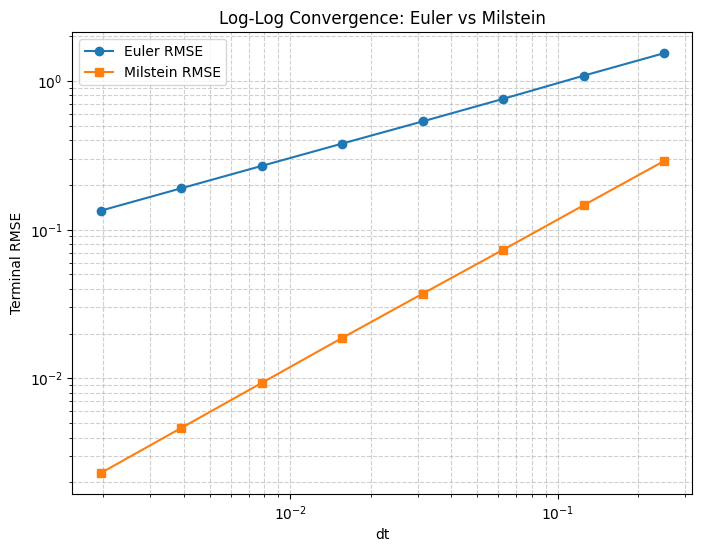

In [9]:
plt.figure(figsize=(8, 6))
plt.loglog(dts, euler_errors, marker='o', label='Euler RMSE')
plt.loglog(dts, milstein_errors, marker='s', label='Milstein RMSE')

plt.xlabel('dt')
plt.ylabel('Terminal RMSE')
plt.title('Log-Log Convergence: Euler vs Milstein')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.show()

In [10]:
log_dts = np.log(dts)
log_euler = np.log(euler_errors)
log_milstein = np.log(milstein_errors)

euler_slope = np.polyfit(log_dts, log_euler, 1)[0]
milstein_slope = np.polyfit(log_dts, log_milstein, 1)[0]

print("Estimated Euler slope:", euler_slope)
print("Estimated Milstein slope:", milstein_slope)

Estimated Euler slope: 0.5024190440759594
Estimated Milstein slope: 0.995268051466122


In [ ]:
# another approach: pathwise max error
# S_euler,S_milstein, S_exact: matrix , shape:(n_paths, time_step+1)
# store the entire path for each simulation, can plot full path
# terminal strong error, pathwise max error, mean squared error

In [ ]:
    S_euler = np.zeros((n_paths, time_steps+1))
    S_milstein = np.zeros((n_paths, time_steps+1))
    S_exact = np.zeros((n_paths, time_steps+1))
    
    S_euler[:, 0] = S0
    S_milstein[:, 0] = S0
    S_exact[:, 0] = S0
    
    for i in range(time_steps):
        S_euler[:, i+1] = S_euler[:, i] * (1 + mu*dt + sigma*dW[:, i])
        
        S_milstein[:, i+1] = S_milstein[:, i] * (
            1 + mu*dt + sigma*dW[:, i] 
            + 0.5*sigma**2*(dW[:, i]**2 - dt)
        )
        
        S_exact[:, i+1] = S_exact[:, i] * np.exp(
            (mu - 0.5*sigma**2)*dt + sigma*dW[:, i]
        )
    
    euler_terminal = np.abs(S_euler[:, -1] - S_exact[:, -1])
    milstein_terminal = np.abs(S_milstein[:, -1] - S_exact[:, -1])

    np.mean(euler_terminal)
    np.mean(milstein_terminal)

    euler_path_error = np.max(np.abs(S_euler - S_exact), axis=1)
    milstein_path_error = np.max(np.abs(S_milstein - S_exact), axis=1)

    np.mean((S_euler[:, -1] - S_exact[:, -1])**2)
    np.mean((S_milstein[:, -1] - S_exact[:, -1])**2)
    